In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
# Load dataset
df = pd.read_csv('/home/pooja/Downloads/Unemployment in India.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Convert date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [13]:
# Rename for ease
df.rename(columns={'Estimated Unemployment Rate (%)': 'Unemployment'}, inplace=True)

# Basic info
print(df.head())
print(df.describe())


           Region       Date Frequency  Unemployment  Estimated Employed  \
0  Andhra Pradesh 2019-05-31   Monthly          3.65          11999139.0   
1  Andhra Pradesh 2019-06-30   Monthly          3.05          11755881.0   
2  Andhra Pradesh 2019-07-31   Monthly          3.75          12086707.0   
3  Andhra Pradesh 2019-08-31   Monthly          3.32          12285693.0   
4  Andhra Pradesh 2019-09-30   Monthly          5.17          12256762.0   

   Estimated Labour Participation Rate (%)   Area  
0                                    43.24  Rural  
1                                    42.05  Rural  
2                                    43.50  Rural  
3                                    43.97  Rural  
4                                    44.68  Rural  
                                Date  Unemployment  Estimated Employed  \
count                            740    740.000000        7.400000e+02   
mean   2019-12-12 18:36:58.378378496     11.787946        7.204460e+06   
min      

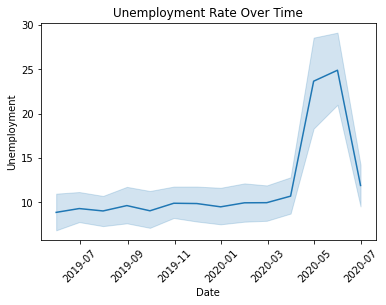

In [14]:

# Plot unemployment over time
plt.figure()
sns.lineplot(data=df, x='Date', y='Unemployment')
plt.title("Unemployment Rate Over Time")
plt.xticks(rotation=45)
plt.show()



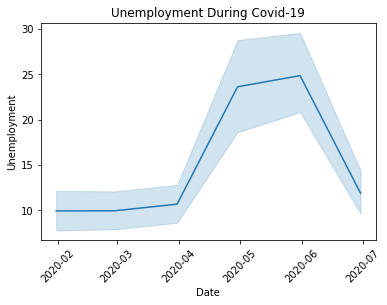

In [15]:
# Covid impact (2020 onwards)
covid_df = df[df['Date'].dt.year >= 2020]

plt.figure()
sns.lineplot(data=covid_df, x='Date', y='Unemployment')
plt.title("Unemployment During Covid-19")
plt.xticks(rotation=45)
plt.show()



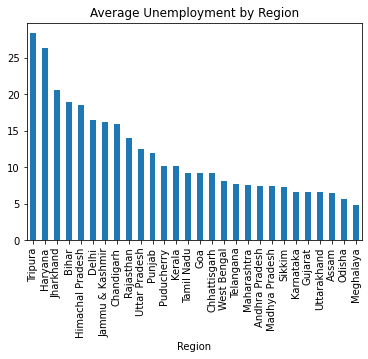

In [16]:
# State-wise average unemployment
state_avg = df.groupby('Region')['Unemployment'].mean().sort_values(ascending=False)

plt.figure()
state_avg.plot(kind='bar')
plt.title("Average Unemployment by Region")
plt.show()